## Postprocess Data (CME)
- Input: `outputs/logs/***/***/phase2_**_**_**_**/checkpoint_**` (PINN results)
- Output: `outputs/logs/***/***/phase2_**_**_**_**/verts_**.vtk` (Curvature etc)

In [2]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

sys.path.append('../../../utils')
from fonts.mpl_fonts import set_arial_font
set_arial_font()

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import math
import matplotlib.pyplot as plt
from flax.training import checkpoints

[mpl_fonts] Using font: Arial
[mpl_fonts] Font dir: /mmfs1/gscratch/matsulab/utils/fonts


In [21]:
## To reload

import importlib
import pinn.normal_curves as normal_curves
importlib.reload(normal_curves)

<module 'pinn.normal_curves' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/pinn/normal_curves.py'>

### Calculate normal, curvature, and force

In [4]:
from pinn.normal_curves import write_vtk_polydata, calc_norm_curv_K_force

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
data_id = "jrc_cos7-1b"
# shape = "bud-11"
step = 10000
phase = 2

N_voxel = 176
voxel_size = 4 # nm

half_length = N_voxel * voxel_size / 2.0

if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

for shape in ["bud-07", "bud-09", "bud-10", "bud-11", "bud-12"]:

    # ==== Load checkpoint data =====
    # checkpoint_dir = f"../outputs/logs/{data_id}/{shape}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
    checkpoint_dir = f"../outputs/logs/{data_id}/unscaled/{shape}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
    checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    print(checkpoint_path)
    
    # ==== Calculate quantities =====
    verts, faces, norms, theta, curvs, gauss, force = calc_norm_curv_K_force(checkpoint_data, half_length=half_length)
    
    ## ==== Save NPZ =====
    # npz_path = f"{checkpoint_dir}/verts_{step}.npz"
    npz_path = f"{checkpoint_dir}/verts_{step}_unit.npz"
    np.savez(npz_path, verts=verts, faces=faces, norms=norms, theta = theta, curvs=curvs, gauss=gauss, force=force)
    
    ## ==== Save VTK =====
    # vtk_path = f"{checkpoint_dir}/verts_{step}.vtk"
    vtk_path = f"{checkpoint_dir}/verts_{step}_{shape}.vtk"
    write_vtk_polydata(vtk_path, verts, faces,
                       point_vectors={"Normal": norms, "Force": force},
                       point_scalars={"MeanCurvature": curvs, "GaussianCurvature": gauss, "Angle": theta})

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-07/phase2_100000_1_100000_10/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-09/phase2_100000_1_100000_10/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-10/phase2_100000_1_100000_10/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-11/phase2_100000_1_100000_10/checkpoint_10000
/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/unscaled/bud-12/phase2_100000_1_100000_10/checkpoint_10000


### Plot Outputs

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase2_100000_1_100000_10/checkpoint_10000


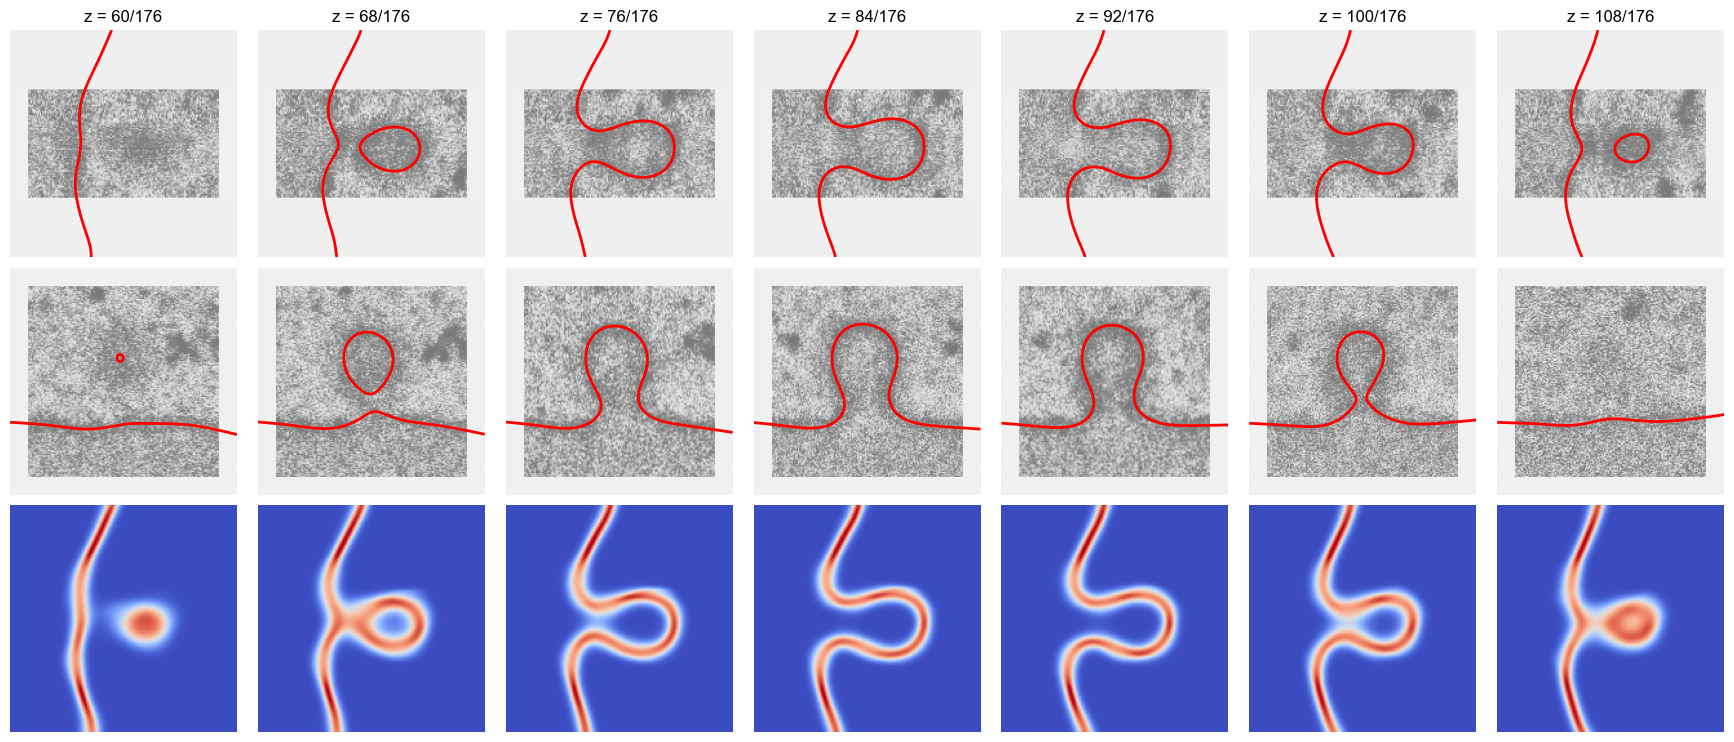

In [32]:
from pinn.plot import visualize_cryoET_with_contours, visualize_phase
import tifffile as tiff

# ==== Parameters =====
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 10
data_id = "jrc_cos7-1b"
shape = "bud-11"
step = 10000
phase = 2
axis = "z"
slices = list(range(60, 110, 8))
# slices = list(range(90, 100, 1))
voxel_scale = (1.27, 1.0, 1.0)
# voxel_scale = (1,1,1)

if phase == 0:
    _lambda_2 = 0
    _lambda_4 = 0
elif phase == 1:
    _lambda_2 = lambda_2
    _lambda_4 = 0
elif phase == 2:
    _lambda_2 = lambda_2
    _lambda_4 = lambda_4

# ==== Load checkpoint data =====
checkpoint_dir = f"../outputs/logs/{data_id}/{shape}/phase{phase}_{lambda_1}_{_lambda_2}_{lambda_3}_{_lambda_4}"
checkpoint_path = os.path.abspath(f"{checkpoint_dir}/checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

# ===== Load cryoET data =====
tif_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
cryoET_data = tiff.imread(tif_file_path)
cryoET_data = 1 - cryoET_data
grid_size = cryoET_data.shape[0]

# ==== Plot output =====
n = len(slices)
fig, axes = plt.subplots(3, n, figsize=(2.5*n, 2.5*3))

# --- row 1: cryoET + contour ---
for ax, slice_index in zip(axes[0], slices):
    visualize_cryoET_with_contours(
        ax, step, checkpoint_data, cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis=axis, no_label=True, voxel_scale=voxel_scale,
    )
    ax.set_title(f"{axis} = {slice_index}/{grid_size}")

# --- row 2: phi ---
for ax, slice_index in zip(axes[1], slices):
    # visualize_phase(
    #     ax, epsilon=0.05, checkpoint=checkpoint_data, component="phi", grid_size=grid_size,
    #     slice_index=slice_index, axis=axis, no_label=True, vmin=-1, vmax=1, voxel_scale=voxel_scale,
    # )
    visualize_cryoET_with_contours(
        ax, step, checkpoint_data, cryoET_data, grid_size=grid_size, 
        slice_index=slice_index, axis="x", no_label=True, voxel_scale=voxel_scale,
    )

# --- row 3: tension ---
for ax, slice_index in zip(axes[2], slices):
    visualize_phase(
        ax, epsilon=0.05, checkpoint=checkpoint_data, component="tension", grid_size=grid_size,
        slice_index=slice_index, axis=axis, no_label=True, vmin=0.0, vmax=1.0, voxel_scale=voxel_scale,
    )

plt.tight_layout()
plt.show()